In [1]:
import pandas as pd
import numpy as np
import re
import random
import time

from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from nltk.translate.bleu_score import corpus_bleu

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
train_sa = pd.read_csv("train_sa_10000.csv")
train_en = pd.read_csv("train_en_10000.csv")

dev_sa = pd.read_csv("dev_sa_1000.csv")
dev_en = pd.read_csv("dev_en_1000.csv")

test_sa = pd.read_csv("test_sa_1000.csv")
test_en = pd.read_csv("test_en_1000.csv")


In [4]:
print(train_sa.columns)
print(train_en.columns)

Index(['Source_id', 'Sentence_sa'], dtype='object')
Index(['Source_id', 'Sentence_en'], dtype='object')


In [5]:
train = train_sa.merge(train_en, on="Source_id")
dev = dev_sa.merge(dev_en, on="Source_id")

In [6]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [7]:
print("train columns:")
print(train.columns.tolist())

print("\ndev columns:")
print(dev.columns.tolist())

print("\ntest_sa columns:")
print(test_sa.columns.tolist())

train columns:
['Source_id', 'Sentence_sa', 'Sentence_en']

dev columns:
['Source_id', 'Sentence_sa', 'Sentence_en']

test_sa columns:
['Source_id', 'Sentence_sa']


In [8]:
train["Sentence_sa"] = train["Sentence_sa"].apply(clean_text)
train["Sentence_en"] = train["Sentence_en"].apply(clean_text)

dev["Sentence_sa"] = dev["Sentence_sa"].apply(clean_text)
dev["Sentence_en"] = dev["Sentence_en"].apply(clean_text)

test_sa["Sentence_sa"] = test_sa["Sentence_sa"].apply(clean_text)

In [9]:
SPECIAL_TOKENS = ["<pad>", "<unk>", "<sos>", "<eos>"]

In [10]:
def build_vocab(sentences, min_freq=1):

    counter = Counter()

    for sent in sentences:
        counter.update(sent.split())

    vocab = SPECIAL_TOKENS.copy()

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab.append(word)

    word2idx = {w:i for i,w in enumerate(vocab)}
    idx2word = {i:w for w,i in word2idx.items()}

    return word2idx, idx2word

In [11]:
src_vocab, src_idx = build_vocab(train["Sentence_sa"])
tgt_vocab, tgt_idx = build_vocab(train["Sentence_en"])

In [12]:
print(len(src_vocab))
print(len(tgt_vocab))

32757
17632


In [13]:
def encode(sentence, vocab):

    tokens = sentence.split()

    ids = [vocab["<sos>"]]

    for t in tokens:
        ids.append(vocab.get(t, vocab["<unk>"]))

    ids.append(vocab["<eos>"])

    return ids

In [14]:
train_src = [encode(s, src_vocab) for s in train["Sentence_sa"]]
train_tgt = [encode(s, tgt_vocab) for s in train["Sentence_en"]]

dev_src = [encode(s, src_vocab) for s in dev["Sentence_sa"]]
dev_tgt = [encode(s, tgt_vocab) for s in dev["Sentence_en"]]

test_src = [encode(s, src_vocab) for s in test_sa["Sentence_sa"]]

In [15]:
class TranslationDataset(Dataset):

    def __init__(self, src, tgt=None):

        self.src = src
        self.tgt = tgt

    def __len__(self):

        return len(self.src)

    def __getitem__(self, idx):

        if self.tgt is None:
            return self.src[idx]

        return self.src[idx], self.tgt[idx]

In [16]:
from torch.nn.utils.rnn import pad_sequence

In [17]:
def collate(batch):

    src = [torch.tensor(x[0]) for x in batch]
    tgt = [torch.tensor(x[1]) for x in batch]

    src = pad_sequence(src,
                       batch_first=True,
                       padding_value=src_vocab["<pad>"])

    tgt = pad_sequence(tgt,
                       batch_first=True,
                       padding_value=tgt_vocab["<pad>"])

    return src, tgt

In [18]:
train_dataset = TranslationDataset(train_src, train_tgt)
dev_dataset = TranslationDataset(dev_src, dev_tgt)

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate
)

In [20]:
for s, t in train_loader:
    print(s.shape)
    print(t.shape)
    break

torch.Size([32, 38])
torch.Size([32, 39])


In [21]:
EMBED_SIZE = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 2
DROPOUT = 0.3

In [22]:
import torch
import torch.nn as nn

class Encoder(nn.Module):

    def __init__(self,
                 input_dim,
                 embed_dim,
                 hidden_dim,
                 num_layers,
                 dropout):

        super().__init__()

        self.embedding = nn.Embedding(
            input_dim,
            embed_dim,
            padding_idx=src_vocab["<pad>"]
        )

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            bidirectional=True,
            batch_first=True
        )

        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell = nn.Linear(hidden_dim * 2, hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        embedded = self.dropout(self.embedding(x))

        outputs, (hidden, cell) = self.lstm(embedded)

        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        cell = torch.cat((cell[-2], cell[-1]), dim=1)

        hidden = torch.tanh(self.fc_hidden(hidden))
        cell = torch.tanh(self.fc_cell(cell))

        return outputs, hidden, cell

In [23]:
encoder = Encoder(
    input_dim=len(src_vocab),
    embed_dim=EMBED_SIZE,
    hidden_dim=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

In [24]:
for src, tgt in train_loader:

    src = src.to(device)

    outputs, hidden, cell = encoder(src)

    print("Source shape :", src.shape)
    print("Encoder outputs :", outputs.shape)
    print("Hidden :", hidden.shape)
    print("Cell :", cell.shape)

    break

Source shape : torch.Size([32, 22])
Encoder outputs : torch.Size([32, 22, 1024])
Hidden : torch.Size([32, 512])
Cell : torch.Size([32, 512])


In [25]:
class BahdanauAttention(nn.Module):

    def __init__(self, hidden_size):

        super().__init__()

        self.attn = nn.Linear(hidden_size * 3, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        # hidden:
        # (batch_size, hidden_size)

        batch_size = encoder_outputs.shape[0]
        src_len = encoder_outputs.shape[1]

        # Repeat decoder hidden state
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        # encoder_outputs:
        # (batch, src_len, hidden*2)

        energy = torch.tanh(
            self.attn(
                torch.cat((hidden, encoder_outputs), dim=2)
            )
        )

        attention = self.v(energy).squeeze(2)

        attention = torch.softmax(attention, dim=1)

        return attention

In [26]:
attention = BahdanauAttention(HIDDEN_SIZE).to(device)

In [27]:
for src, tgt in train_loader:

    src = src.to(device)

    encoder_outputs, hidden, cell = encoder(src)

    attn_weights = attention(hidden, encoder_outputs)

    print("Attention shape:", attn_weights.shape)

    break

Attention shape: torch.Size([32, 23])


In [28]:
print(attn_weights[0])
print(attn_weights[0].sum())

tensor([0.0431, 0.0436, 0.0440, 0.0440, 0.0439, 0.0434, 0.0431, 0.0430, 0.0427,
        0.0423, 0.0428, 0.0434, 0.0436, 0.0436, 0.0438, 0.0433, 0.0435, 0.0437,
        0.0438, 0.0438, 0.0439, 0.0439, 0.0439], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(1., device='cuda:0', grad_fn=<SumBackward0>)


In [29]:
class Decoder(nn.Module):

    def __init__(self,
                 output_dim,
                 embed_dim,
                 hidden_dim,
                 num_layers,
                 dropout,
                 attention):

        super().__init__()

        self.output_dim = output_dim
        self.hidden_dim = hidden_dim

        self.attention = attention

        self.embedding = nn.Embedding(
            output_dim,
            embed_dim,
            padding_idx=tgt_vocab["<pad>"]
        )

        self.lstm = nn.LSTM(
            embed_dim + hidden_dim * 2,
            hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim * 3 + embed_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self,
                input_word,
                hidden,
                cell,
                encoder_outputs):

        input_word = input_word.unsqueeze(1)

        embedded = self.dropout(
            self.embedding(input_word)
        )

        attention = self.attention(
            hidden,
            encoder_outputs
        )

        attention = attention.unsqueeze(1)

        context = torch.bmm(
            attention,
            encoder_outputs
        )

        lstm_input = torch.cat(
            (embedded, context),
            dim=2
        )

        output, (hidden, cell) = self.lstm(
            lstm_input,
            (
                hidden.unsqueeze(0),
                cell.unsqueeze(0)
            )
        )

        prediction = self.fc(
            torch.cat(
                (
                    output.squeeze(1),
                    context.squeeze(1),
                    embedded.squeeze(1)
                ),
                dim=1
            )
        )

        return prediction, hidden.squeeze(0), cell.squeeze(0)

In [30]:
decoder = Decoder(
    output_dim=len(tgt_vocab),
    embed_dim=EMBED_SIZE,
    hidden_dim=HIDDEN_SIZE,
    num_layers=1,
    dropout=DROPOUT,
    attention=attention
).to(device)

In [31]:
for src, tgt in train_loader:

    src = src.to(device)

    encoder_outputs, hidden, cell = encoder(src)

    first_word = torch.full(
        (src.size(0),),
        tgt_vocab["<sos>"],
        dtype=torch.long,
        device=device
    )

    prediction, hidden, cell = decoder(
        first_word,
        hidden,
        cell,
        encoder_outputs
    )

    print("Prediction shape:", prediction.shape)
    print("Hidden shape:", hidden.shape)
    print("Cell shape:", cell.shape)

    break

Prediction shape: torch.Size([32, 17632])
Hidden shape: torch.Size([32, 512])
Cell shape: torch.Size([32, 512])


In [32]:
import random
import torch
import torch.nn as nn


class Seq2Seq(nn.Module):

    def __init__(self,
                 encoder,
                 decoder,
                 device):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self,
                src,
                trg,
                teacher_forcing_ratio=0.5):

        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            vocab_size
        ).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        input_word = trg[:, 0]

        for t in range(1, trg_len):

            prediction, hidden, cell = self.decoder(
                input_word,
                hidden,
                cell,
                encoder_outputs
            )

            outputs[:, t] = prediction

            best_guess = prediction.argmax(1)

            if random.random() < teacher_forcing_ratio:
                input_word = trg[:, t]
            else:
                input_word = best_guess

        return outputs

In [33]:
model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)

In [34]:
for src, tgt in train_loader:

    src = src.to(device)
    tgt = tgt.to(device)

    output = model(src, tgt)

    print("Source :", src.shape)
    print("Target :", tgt.shape)
    print("Output :", output.shape)

    break

Source : torch.Size([32, 26])
Target : torch.Size([32, 33])
Output : torch.Size([32, 33, 17632])


In [35]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters : 59478496
Trainable Parameters : 59478496


In [36]:
EMBED_SIZE = 256
HIDDEN_SIZE = 256
NUM_LAYERS = 2

In [37]:
encoder = Encoder(
    input_dim=len(src_vocab),
    embed_dim=EMBED_SIZE,
    hidden_dim=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

In [38]:
attention = BahdanauAttention(HIDDEN_SIZE).to(device)

In [39]:
decoder = Decoder(
    output_dim=len(tgt_vocab),
    embed_dim=EMBED_SIZE,
    hidden_dim=HIDDEN_SIZE,
    num_layers=1,
    dropout=DROPOUT,
    attention=attention
).to(device)

In [40]:
model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)

In [41]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 35,112,416


In [42]:
min_freq = 2

In [43]:
src_vocab, src_idx = build_vocab(
    train["Sentence_sa"],
    min_freq=3
)

tgt_vocab, tgt_idx = build_vocab(
    train["Sentence_en"],
    min_freq=3
)

In [44]:
print("Source Vocabulary:", len(src_vocab))
print("Target Vocabulary:", len(tgt_vocab))

Source Vocabulary: 4795
Target Vocabulary: 4598


In [45]:
train_src = [encode(s, src_vocab) for s in train["Sentence_sa"]]
train_tgt = [encode(s, tgt_vocab) for s in train["Sentence_en"]]

dev_src = [encode(s, src_vocab) for s in dev["Sentence_sa"]]
dev_tgt = [encode(s, tgt_vocab) for s in dev["Sentence_en"]]

test_src = [encode(s, src_vocab) for s in test_sa["Sentence_sa"]]

In [46]:
train_dataset = TranslationDataset(train_src, train_tgt)
dev_dataset = TranslationDataset(dev_src, dev_tgt)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate
)

In [47]:
EMBED_SIZE = 256
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.3

In [48]:
encoder = Encoder(
    input_dim=len(src_vocab),
    embed_dim=EMBED_SIZE,
    hidden_dim=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

In [49]:
attention = BahdanauAttention(
    HIDDEN_SIZE
).to(device)

In [50]:
decoder = Decoder(
    output_dim=len(tgt_vocab),
    embed_dim=EMBED_SIZE,
    hidden_dim=HIDDEN_SIZE,
    num_layers=1,
    dropout=DROPOUT,
    attention=attention
).to(device)

In [51]:
model = Seq2Seq(
    encoder,
    decoder,
    device
).to(device)

In [52]:
criterion = nn.CrossEntropyLoss(
    ignore_index=tgt_vocab["<pad>"]
)

In [53]:
import torch.optim as optim

In [54]:
optimizer = optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)

In [55]:
total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Source Vocabulary : {len(src_vocab):,}")
print(f"Target Vocabulary : {len(tgt_vocab):,}")

print(f"Total Parameters : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Source Vocabulary : 4,795
Target Vocabulary : 4,598
Total Parameters : 11,257,590
Trainable Parameters : 11,257,590


In [56]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [57]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [58]:
criterion = nn.CrossEntropyLoss(
    ignore_index=tgt_vocab["<pad>"]
)

In [59]:
def teacher_forcing(epoch):

    if epoch < 5:
        return 1.0

    elif epoch < 10:
        return 0.8

    elif epoch < 15:
        return 0.6

    elif epoch < 20:
        return 0.4

    else:
        return 0.2

In [60]:
def train_epoch(model,
                loader,
                optimizer,
                criterion,
                epoch,
                clip=1):

    model.train()

    epoch_loss = 0

    tf_ratio = teacher_forcing(epoch)

    for src, tgt in loader:

        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        output = model(
            src,
            tgt,
            teacher_forcing_ratio=tf_ratio
        )

        output_dim = output.shape[-1]

        output = output[:,1:].reshape(-1, output_dim)
        target = tgt[:,1:].reshape(-1)

        loss = criterion(output, target)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [61]:
def evaluate(model,
             loader,
             criterion):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src, tgt in loader:

            src = src.to(device)
            tgt = tgt.to(device)

            output = model(
                src,
                tgt,
                teacher_forcing_ratio=0
            )

            output_dim = output.shape[-1]

            output = output[:,1:].reshape(-1, output_dim)
            target = tgt[:,1:].reshape(-1)

            loss = criterion(output, target)

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [62]:
N_EPOCHS = 20

best_valid_loss = float("inf")

patience = 3

counter = 0

In [63]:
import time

train_losses = []
valid_losses = []

for epoch in range(N_EPOCHS):

    start = time.time()

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        epoch
    )

    valid_loss = evaluate(
        model,
        dev_loader,
        criterion
    )
    # NEW
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    scheduler.step(valid_loss)

    end = time.time()

    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss

        counter = 0

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

    else:

        counter += 1

    lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1:02d}"
        f" | TF={teacher_forcing(epoch):.1f}"
        f" | LR={lr:.6f}"
        f" | Train={train_loss:.4f}"
        f" | Valid={valid_loss:.4f}"
        f" | Time={end-start:.1f}s"
    )



Epoch 01 | TF=1.0 | LR=0.001000 | Train=5.2750 | Valid=5.6727 | Time=35.4s
Epoch 02 | TF=1.0 | LR=0.001000 | Train=4.3971 | Valid=5.6623 | Time=35.0s
Epoch 03 | TF=1.0 | LR=0.001000 | Train=3.9692 | Valid=5.7098 | Time=35.2s
Epoch 04 | TF=1.0 | LR=0.001000 | Train=3.6489 | Valid=5.8097 | Time=35.3s
Epoch 05 | TF=1.0 | LR=0.000500 | Train=3.3698 | Valid=5.8045 | Time=35.1s
Epoch 06 | TF=0.8 | LR=0.000500 | Train=3.4316 | Valid=5.4523 | Time=35.2s
Epoch 07 | TF=0.8 | LR=0.000500 | Train=3.2469 | Valid=5.4545 | Time=34.6s
Epoch 08 | TF=0.8 | LR=0.000500 | Train=3.1098 | Valid=5.4208 | Time=36.0s
Epoch 09 | TF=0.8 | LR=0.000500 | Train=2.9339 | Valid=5.4295 | Time=35.6s
Epoch 10 | TF=0.8 | LR=0.000500 | Train=2.7711 | Valid=5.4898 | Time=35.3s
Epoch 11 | TF=0.6 | LR=0.000500 | Train=3.0289 | Valid=5.2727 | Time=35.6s
Epoch 12 | TF=0.6 | LR=0.000500 | Train=2.8757 | Valid=5.2823 | Time=35.0s
Epoch 13 | TF=0.6 | LR=0.000500 | Train=2.7453 | Valid=5.2798 | Time=35.4s
Epoch 14 | TF=0.6 | LR=0.

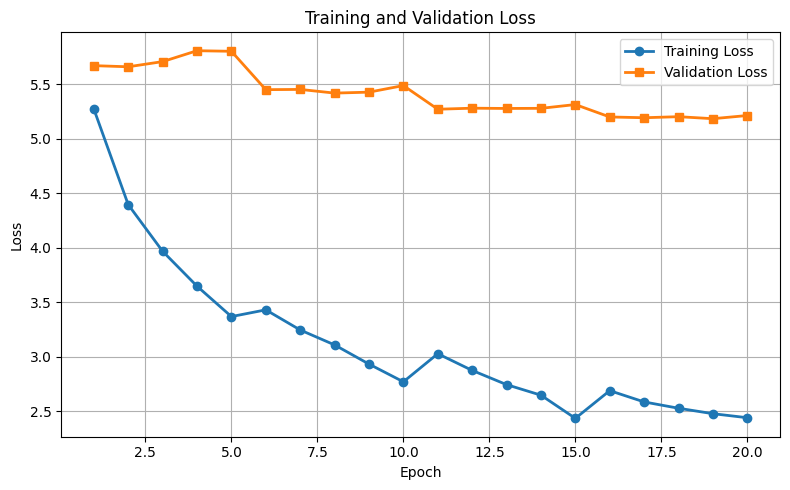

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    range(1, len(valid_losses)+1),
    valid_losses,
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("training_validation_loss.png", dpi=300)

plt.show()

In [65]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(4795, 256, padding_idx=0)
    (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (fc_hidden): Linear(in_features=512, out_features=256, bias=True)
    (fc_cell): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (attn): Linear(in_features=768, out_features=256, bias=True)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(4598, 256, padding_idx=0)
    (lstm): LSTM(768, 256, batch_first=True)
    (fc): Linear(in_features=1024, out_features=4598, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [66]:
import torch
import torch.nn.functional as F

idx2tgt = {v: k for k, v in tgt_vocab.items()}

def beam_search_translate(model,
                          sentence,
                          beam_width=3,
                          max_len=50):

    model.eval()

    with torch.no_grad():

        src = torch.tensor(sentence, dtype=torch.long).unsqueeze(0).to(device)

        encoder_outputs, hidden, cell = model.encoder(src)

        beams = [
            (
                [tgt_vocab["<sos>"]],
                0.0,
                hidden,
                cell
            )
        ]

        completed = []

        for _ in range(max_len):

            candidates = []

            for seq, score, h, c in beams:

                last_token = seq[-1]

                if last_token == tgt_vocab["<eos>"]:
                    completed.append((seq, score))
                    continue

                inp = torch.tensor(
                    [last_token],
                    dtype=torch.long,
                    device=device
                )

                prediction, h_new, c_new = model.decoder(
                    inp,
                    h,
                    c,
                    encoder_outputs
                )

                log_probs = F.log_softmax(prediction, dim=1)

                top_scores, top_tokens = torch.topk(
                    log_probs,
                    beam_width
                )

                for i in range(beam_width):

                    token = top_tokens[0, i].item()

                    candidates.append(
                        (
                            seq + [token],
                            score + top_scores[0, i].item(),
                            h_new,
                            c_new
                        )
                    )

            if len(candidates) == 0:
                break

            candidates = sorted(
                candidates,
                key=lambda x: x[1],
                reverse=True
            )

            beams = candidates[:beam_width]

        if len(completed) == 0:
            completed = beams

        best_sequence = max(
            completed,
            key=lambda x: x[1]
        )[0]

        words = []

        for token in best_sequence:

            word = idx2tgt[token]

            if word in ["<pad>", "<sos>", "<eos>"]:
                continue

            words.append(word)

        return " ".join(words)

In [67]:
beam_search_translate(
    model,
    test_src[0],
    beam_width=3
)

'it also allows us to a java package manager.'

In [68]:
print("beam_search_translate" in globals())

True


In [69]:
import torch
import torch.nn.functional as F

idx2tgt = {v: k for k, v in tgt_vocab.items()}

In [70]:
def beam_search_translate(
    model,
    sentence,
    beam_width=3,
    max_len=50
):

    model.eval()

    with torch.no_grad():

        src = torch.tensor(sentence).unsqueeze(0).to(device)

        encoder_outputs, hidden, cell = model.encoder(src)

        beams = [(
            [tgt_vocab["<sos>"]],
            0.0,
            hidden,
            cell
        )]

        completed = []

        for _ in range(max_len):

            new_beams = []

            for seq, score, h, c in beams:

                last_word = seq[-1]

                if last_word == tgt_vocab["<eos>"]:
                    completed.append((seq, score))
                    continue

                inp = torch.tensor([last_word], device=device)

                prediction, h_new, c_new = model.decoder(
                    inp,
                    h,
                    c,
                    encoder_outputs
                )

                log_probs = F.log_softmax(prediction, dim=1)

                top_probs, top_idx = torch.topk(
                    log_probs,
                    beam_width
                )

                for k in range(beam_width):

                    next_word = top_idx[0][k].item()

                    next_score = score + top_probs[0][k].item()

                    new_seq = seq + [next_word]

                    new_beams.append((
                        new_seq,
                        next_score,
                        h_new,
                        c_new
                    ))

            if len(new_beams) == 0:
                break

            new_beams = sorted(
                new_beams,
                key=lambda x: x[1],
                reverse=True
            )

            beams = new_beams[:beam_width]

        if len(completed) == 0:
            completed = beams

        best_seq = max(
            completed,
            key=lambda x: x[1]
        )[0]

        words = []

        for idx in best_seq:

            word = idx2tgt[idx]

            if word in ["<pad>", "<sos>", "<eos>"]:
                continue

            words.append(word)

        return " ".join(words)

In [71]:
predictions=[]

for sentence in dev_src:

    predictions.append(
        beam_search_translate(
            model,
            sentence,
            beam_width=3
        )
    )

print(predictions[:5])

['those two are <unk>', 'now, i will back to the <unk> <unk>', '"and the king of the <unk> and they were <unk> and they were <unk> <unk>', 'these are <unk>', '<unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>']


In [72]:
pip install nltk

In [73]:
print(type(dev_src))
print(type(dev_tgt))

<class 'list'>
<class 'list'>


In [74]:
from nltk.translate.bleu_score import corpus_bleu

references = [
    [x.split()]
    for x in dev["Sentence_en"]
]

hypotheses = [
    x.split()
    for x in predictions
]

bleu = corpus_bleu(
    references,
    hypotheses
)

print("BLEU:", bleu)

BLEU: 0.054429310165918704


In [75]:
pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00


In [76]:
from bert_score import score

references = dev["Sentence_en"].tolist()

P, R, F1 = score(
    predictions,
    references,
    lang="en",
    rescale_with_baseline=True
)

print("BERTScore F1:", F1.mean().item())

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: -0.021422021090984344


In [77]:
import time

model.eval()

predictions = []

start_time = time.time()

for sentence in test_src:

    prediction = beam_search_translate(
      model,
      sentence,
      beam_width=3
  )

    predictions.append(prediction)

end_time = time.time()

inference_time = end_time - start_time

print(f"Total Inference Time : {inference_time:.4f} seconds")
print(f"Average Time per Sentence : {inference_time/len(test_src):.4f} seconds")

Total Inference Time : 115.5371 seconds
Average Time per Sentence : 0.1155 seconds


In [78]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters : 11257590
Trainable Parameters : 11257590


In [79]:
model_size_mb = total_params * 4 / (1024 ** 2)

print(f"Approximate Model Size : {model_size_mb:.2f} MB")

Approximate Model Size : 42.94 MB


In [80]:
import pandas as pd

# Create a dictionary of final results
results = {
    "Metric": [
        "BLEU Score",
        "BERTScore F1",
        "Inference Time (seconds)",
        "Average Inference Time per Sentence (seconds)",
        "Total Parameters",
        "Trainable Parameters"
    ],
    "Value": [
        float(bleu),
        float(F1.mean().item()),
        float(inference_time),
        float(inference_time / len(test_src)),
        int(total_params),
        int(trainable_params)
    ]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Print results
print("=" * 60)
print("FINAL EVALUATION RESULTS")
print("=" * 60)
print(results_df)

# Save results
results_df.to_csv("evaluation_results2.csv", index=False)

print("\nEvaluation results saved successfully as 'submission.csv'")

FINAL EVALUATION RESULTS
                                          Metric         Value
0                                     BLEU Score  5.442931e-02
1                                   BERTScore F1 -2.142202e-02
2                       Inference Time (seconds)  1.155371e+02
3  Average Inference Time per Sentence (seconds)  1.155371e-01
4                               Total Parameters  1.125759e+07
5                           Trainable Parameters  1.125759e+07

Evaluation results saved successfully as 'submission.csv'
